# 29_geo_deeponet_v2.ipynb

GeoDeepONet v2 — расширенная capacity версия v1 (`17_geo_deeponet_train_v1`).

## Что изменилось vs v1

| Параметр | v1 | **v2** |
|---|---|---|
| `embed_dim` | 32 | **64** |
| `branch_hidden` | 64 | **128** |
| `branch_width` (= trunk_width) | 192 | **384** |
| `trunk_hidden` | 256 | **512** |
| `num_fourier_features` | 24 | **32** |
| total params | ~256K | **~1.2M** (≈5×) |

## Что НЕ изменилось

Это критично:

- **Source/receiver aggregation: sum затем mean.** Это и есть тот шаг, который
  даёт **точную** геометрическую инвариантность (1e-7 на v1). Любое изменение
  её сломает.
- **Per-token MLP применяется поэлементно**, ни одно из изменений не вводит
  взаимодействие между токенами до aggregation. Инвариантность сохранится.
- **Trunk** — та же архитектура, просто шире и глубже по hidden.
- **Тренировочный протокол** — AdamW + ReduceLROnPlateau, weight_decay=1e-6,
  dropout=0. v2 GeoUNet/FNO показали, что регуляризация в этой задаче
  снижает качество — поэтому не добавляем.

## Зачем расширять именно эти компоненты

В диагностике мы видели, что:

- **DeepONet (vanilla) — самая OOD-устойчивая** модель (test=13.93), и её
  выразительность лежит в **trunk-базисе** + dot product, а не в branch CNN.
- **GeoDeepONet v1** при том же дизайне, но per-token MLP branch'е (256K vs
  5M у DeepONet) дал test=17.08 — отставание 3 м/с при capacity в 20× меньше.

Этот ноутбук пытается это отставание сократить расширением:

1. **Trunk** — больше базисных функций (`trunk_width 192→384`) и более
   глубокого hidden (`256→512`). Trunk — главный носитель OOD-обобщения
   (он не зависит от входа, только от координат пикселей).
2. **branch_proj** автоматически расширяется до `branch_width=384`, чтобы
   формы matmul сошлись.
3. **`embed_dim`/`branch_hidden`** — модерация: даём branch'у больше
   capacity, но без переусердствования (v2 GeoUNet с capacity x17 показал,
   что просто capacity не помогает).
4. **Fourier features 24→32** — позволяет trunk'у выразить более мелкие
   пространственные структуры в реконструкции.

## Ожидаемые результаты

- **Геометрическая инвариантность**: остается **0** или ~1e-7 (как в v1).
  Sanity-тесты должны это подтвердить.
- **OOD test RMSE**: 14-16 м/с (с 17.08 в v1), приближается к vanilla
  DeepONet (13.93).
- **Within-distribution (val)**: 10-12 м/с (с 12.95 в v1).
- **best_epoch**: 70-100 (v1 тренировалась долго — больше capacity = ещё дольше).

## 1. Импорты и конфиг

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu128
cuda available: True
device name: NVIDIA GeForce RTX 5090


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "run_name": "geo_deeponet_v2",
    "batch_size": 8,
    "epochs": 1000,
    "patience": 35,
    "lr": 1e-3,
    "min_lr": 1e-5,
    "weight_decay": 1e-6,            # unchanged from v1
    "num_workers": 0,
    "mask_half_width": 2,
    "use_residual": True,

    # Branch (geometry-conditioned) — EXPANDED in v2
    "token_dim": 8,
    "branch_hidden": 128,             # v1: 64
    "embed_dim": 64,                  # v1: 32
    "source_aggregation": "sum",
    "receiver_aggregation": "mean",
    "branch_width": 384,              # v1: 192

    # Trunk — EXPANDED in v2
    "trunk_width": 384,               # v1: 192 (must equal branch_width)
    "trunk_hidden": 512,              # v1: 256
    "num_fourier_features": 32,       # v1: 24
    "dropout": 0.0,                   # unchanged

    # LR schedule
    "scheduler_factor": 0.5,
    "scheduler_patience": 8,

    # Optional debug
    "overfit_debug_enabled": True,
    "overfit_subset_size": 8,
    "overfit_epochs": 300,
    "overfit_lr": 1e-3,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'run_name': 'geo_deeponet_v2',
 'batch_size': 8,
 'epochs': 1000,
 'patience': 35,
 'lr': 0.001,
 'min_lr': 1e-05,
 'weight_decay': 1e-06,
 'num_workers': 0,
 'mask_half_width': 2,
 'use_residual': True,
 'token_dim': 8,
 'branch_hidden': 128,
 'embed_dim': 64,
 'source_aggregation': 'sum',
 'receiver_aggregation': 'mean',
 'branch_width': 384,
 'trunk_width': 384,
 'trunk_hidden': 512,
 'num_fourier_features': 32,
 'dropout': 0.0,
 'scheduler_factor': 0.5,
 'scheduler_patience': 8,
 'overfit_debug_enabled': True,
 'overfit_subset_size': 8,
 'overfit_epochs': 300,
 'overfit_lr': 0.001}

## 2. Файлы и статистика по target

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"

assert TRAIN_DIR.exists(), TRAIN_DIR
assert VAL_DIR.exists(), VAL_DIR
assert TEST_DIR.exists(), TEST_DIR

train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

print("train:", len(train_files))
print("val:", len(val_files))
print("test:", len(test_files))
assert len(train_files) > 0 and len(val_files) > 0 and len(test_files) > 0

sample0 = np.load(train_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

all_c_values = []
for p in train_files:
    c = np.load(p)["c"].astype(np.float32)
    all_c_values.append(c)
all_c_values = np.stack(all_c_values, axis=0)

stats = {"c_min": float(all_c_values.min()), "c_max": float(all_c_values.max())}
print("S, R:", S, R)
print("H, W:", H, W)
print("dx:", dx)
print("freq_hz:", freq_hz)
print("stats:", stats)

train: 6200
val: 1000
test: 800
S, R: 16 256
H, W: 192 192
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0
stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 3. `M_hom` через j-Wave

Точная копия блока из всех остальных ноутбуков.

In [5]:
import jax
import jax.numpy as jnp
from jax import jit

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [6]:
domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)
    return medium

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

/tmp/ipykernel_1516/1657452440.py:1: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [7]:
c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)

t0 = time.time()
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
t1 = time.time()

M_hom_complex = np.array(M_hom_complex)

print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)
print("time:", t1 - t0, "sec")

M_hom_complex: (16, 256) complex64
time: 8.178250789642334 sec


## 4. Dataset

`USCTGeoDataset` идентичен тому, что в `14_geo_unet_train_v1`.

In [8]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    S_local, R_local = M.shape
    for s in range(S_local):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % R_local
            M[s, rr] = 0.0 + 0.0j
    return M

class USCTGeoDataset(Dataset):
    """Returns (x, c, src_norm, rcv_norm, rcv_pixel, meta).

    Same as in 14_geo_unet_train_v1: we read receiver_y/x and source_ring_idx
    that 04_generate_dataset_v2 already saved into every npz, and produce three
    geometry tensors per sample. No dataset regeneration needed.
    """
    def __init__(self, paths, c_min, c_max, M_hom_complex, H, W,
                 use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)
        self.H = int(H)
        self.W = int(W)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])

        x_raw = d["x"].astype(np.float32)
        c_map = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)
        rcv_y = d["receiver_y"].astype(np.int64)
        rcv_x = d["receiver_x"].astype(np.int64)

        # 1) measurement + residual + self-mask
        M = x_raw[0] + 1j * x_raw[1]
        if self.use_residual:
            M = M - self.M_hom_complex
        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)
        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        # 2) target
        c_norm = self.normalize_target(c_map).astype(np.float32)

        # 3) geometry
        src_y_pix = rcv_y[source_ring_idx]
        src_x_pix = rcv_x[source_ring_idx]

        rcv_pixel = np.stack([rcv_y, rcv_x], axis=-1).astype(np.int64)

        rcv_norm = np.stack([
            rcv_y.astype(np.float32) / max(self.H - 1, 1) * 2 - 1,
            rcv_x.astype(np.float32) / max(self.W - 1, 1) * 2 - 1,
        ], axis=-1).astype(np.float32)
        src_norm = np.stack([
            src_y_pix.astype(np.float32) / max(self.H - 1, 1) * 2 - 1,
            src_x_pix.astype(np.float32) / max(self.W - 1, 1) * 2 - 1,
        ], axis=-1).astype(np.float32)

        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            torch.from_numpy(src_norm),
            torch.from_numpy(rcv_norm),
            torch.from_numpy(rcv_pixel),
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )

In [9]:
ds_train = USCTGeoDataset(
    train_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)
ds_val = USCTGeoDataset(
    val_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)
ds_test = USCTGeoDataset(
    test_files, stats["c_min"], stats["c_max"],
    M_hom_complex=M_hom_complex, H=H, W=W,
    use_residual=CFG["use_residual"],
    mask_half_width=CFG["mask_half_width"],
)

x0, c0, src0, rcv0, rcvp0, meta0 = ds_train[0]
print("x:        ", x0.shape, x0.dtype)
print("c:        ", c0.shape, c0.dtype, float(c0.min()), float(c0.max()))
print("src_norm: ", src0.shape, src0.dtype, "range:", float(src0.min()), float(src0.max()))
print("rcv_norm: ", rcv0.shape, rcv0.dtype, "range:", float(rcv0.min()), float(rcv0.max()))
print("rcv_pixel:", rcvp0.shape, rcvp0.dtype, "range:", int(rcvp0.min()), int(rcvp0.max()))
print(meta0)

x:         torch.Size([2, 16, 256]) torch.float32
c:         torch.Size([1, 192, 192]) torch.float32 -0.7392016053199768 0.5010437965393066
src_norm:  torch.Size([16, 2]) torch.float32 range: -0.7591623067855835 0.7591623067855835
rcv_norm:  torch.Size([256, 2]) torch.float32 range: -0.7591623067855835 0.7591623067855835
rcv_pixel: torch.Size([256, 2]) torch.int64 range: 23 168
{'path': '/workspace/usct_dataset_v2/train/sample_00000.npz', 'x_scale': 5201.529296875}


## 5. Модель: GeoDeepONet

### 5.1 Branch (geometry-conditioned), Trunk и полная модель

In [10]:
class GeometryConditionedBranch(nn.Module):
    """Per-token MLP: (Re, Im, src_xy, rcv_xy, ray_xy) -> embed_dim.

    Identical to the one in 14_geo_unet_train_v1.
    """
    def __init__(self, token_dim=8, hidden_dim=64, embed_dim=32):
        super().__init__()
        self.embed_dim = int(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(token_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embed_dim),
        )

    def forward(self, x_residual, src_norm, rcv_norm):
        B, _, S, R = x_residual.shape
        src = src_norm.unsqueeze(2).expand(B, S, R, 2)
        rcv = rcv_norm.unsqueeze(1).expand(B, S, R, 2)
        ray = rcv - src
        meas = x_residual.permute(0, 2, 3, 1).contiguous()
        tokens = torch.cat([meas, src, rcv, ray], dim=-1)
        return self.mlp(tokens)


class TrunkNetV2(nn.Module):
    """Identical to 12_deeponet_train_v2."""
    def __init__(self, width=192, hidden=256, num_fourier_features=24, dropout=0.0):
        super().__init__()
        self.num_fourier_features = int(num_fourier_features)

        if self.num_fourier_features > 0:
            freq = 2.0 ** torch.arange(self.num_fourier_features, dtype=torch.float32) * math.pi
            self.register_buffer("freq", freq, persistent=False)
            in_dim = 2 + 4 * self.num_fourier_features
        else:
            self.register_buffer("freq", torch.empty(0), persistent=False)
            in_dim = 2

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, width),
        )

    def encode_coords(self, coords):
        if self.num_fourier_features == 0:
            return coords
        y = coords[:, 0:1]
        x = coords[:, 1:2]
        y_proj = y * self.freq[None, :]
        x_proj = x * self.freq[None, :]
        feats = [coords, torch.sin(y_proj), torch.cos(y_proj),
                 torch.sin(x_proj), torch.cos(x_proj)]
        return torch.cat(feats, dim=1)

    def forward(self, coords):
        return self.net(self.encode_coords(coords))


class GeoDeepONet2D(nn.Module):
    """DeepONet with permutation-invariant geometry-conditioned branch."""

    def __init__(self,
                 token_dim=8, branch_hidden=64, embed_dim=32,
                 branch_width=192, trunk_width=192, trunk_hidden=256,
                 num_fourier_features=24, dropout=0.0,
                 source_aggregation="sum", receiver_aggregation="mean",
                 H=192, W=192):
        super().__init__()
        assert source_aggregation in ("sum", "mean")
        assert receiver_aggregation in ("sum", "mean")
        assert branch_width == trunk_width, "branch_width must equal trunk_width"
        self.width = int(branch_width)
        self.H = int(H)
        self.W = int(W)
        self.source_agg = source_aggregation
        self.receiver_agg = receiver_aggregation

        self.branch_tokenizer = GeometryConditionedBranch(
            token_dim=token_dim, hidden_dim=branch_hidden, embed_dim=embed_dim,
        )
        # Project the pooled embedding (embed_dim) up to branch_width.
        self.branch_proj = nn.Sequential(
            nn.Linear(embed_dim, branch_width),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(branch_width, branch_width),
        )

        self.trunk = TrunkNetV2(
            width=trunk_width, hidden=trunk_hidden,
            num_fourier_features=num_fourier_features, dropout=dropout,
        )

        self.bias = nn.Parameter(torch.zeros(1))

    def encode_branch(self, x_residual, src_norm, rcv_norm):
        emb = self.branch_tokenizer(x_residual, src_norm, rcv_norm)   # (B, S, R, C)

        if self.source_agg == "sum":
            agg = emb.sum(dim=1)
        else:
            agg = emb.mean(dim=1)
        # agg: (B, R, C)

        if self.receiver_agg == "sum":
            agg = agg.sum(dim=1)
        else:
            agg = agg.mean(dim=1)
        # agg: (B, C)

        return self.branch_proj(agg)                                   # (B, branch_width)

    def forward(self, x_residual, src_norm, rcv_norm, coords):
        b = self.encode_branch(x_residual, src_norm, rcv_norm)         # (B, W)
        t = self.trunk(coords)                                         # (H*W, W)
        out = torch.matmul(b, t.t()) / math.sqrt(self.width) + self.bias
        return out.view(b.shape[0], 1, self.H, self.W)

### 5.2 Координатная сетка для trunk

То же самое, что в `12_deeponet_train_v2`: один раз заранее считаем `(H*W, 2)` тензор, потом передаём в каждый вызов модели.

In [11]:
# Pixel-grid coords for the trunk (same convention as 12_deeponet_train_v2).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

yy = torch.linspace(-1.0, 1.0, H)
xx = torch.linspace(-1.0, 1.0, W)
gy, gx = torch.meshgrid(yy, xx, indexing="ij")
coords_full = torch.stack([gy.reshape(-1), gx.reshape(-1)], dim=1)
coords_device = coords_full.to(device)

print("coords_device:", coords_device.shape, coords_device.dtype, coords_device.device)

coords_device: torch.Size([36864, 2]) torch.float32 cuda:0


### 5.3 Sanity: число параметров и форма выхода

In [12]:
_test_model = GeoDeepONet2D(
    token_dim=CFG["token_dim"],
    branch_hidden=CFG["branch_hidden"],
    embed_dim=CFG["embed_dim"],
    branch_width=CFG["branch_width"],
    trunk_width=CFG["trunk_width"],
    trunk_hidden=CFG["trunk_hidden"],
    num_fourier_features=CFG["num_fourier_features"],
    dropout=CFG["dropout"],
    source_aggregation=CFG["source_aggregation"],
    receiver_aggregation=CFG["receiver_aggregation"],
    H=H, W=W,
).to(device)

n_params = sum(p.numel() for p in _test_model.parameters())
n_branch_tok = sum(p.numel() for p in _test_model.branch_tokenizer.parameters())
n_branch_proj = sum(p.numel() for p in _test_model.branch_proj.parameters())
n_trunk = sum(p.numel() for p in _test_model.trunk.parameters())

print(f"Total            : {n_params:,}")
print(f"  branch_tokenizer: {n_branch_tok:,}    (v1: ~7K)")
print(f"  branch_proj     : {n_branch_proj:,}    (v1: ~43K)")
print(f"  trunk           : {n_trunk:,}    (v1: ~206K)")
print(f"\n  v2/v1 capacity ratio: ~{n_params / 256_000:.1f}x")

with torch.no_grad():
    _x  = torch.randn(2, 2, S, R, device=device)
    _sn = torch.randn(2, S, 2, device=device)
    _rn = torch.randn(2, R, 2, device=device)
    _y  = _test_model(_x, _sn, _rn, coords_device)
    print("\ninput shape: ", tuple(_x.shape))
    print("output shape:", tuple(_y.shape))
    assert _y.shape == (2, 1, H, W)

del _test_model, _x, _sn, _rn, _y
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Total            : 988,097
  branch_tokenizer: 25,920    (v1: ~7K)
  branch_proj     : 172,800    (v1: ~43K)
  trunk           : 789,376    (v1: ~206K)

  v2/v1 capacity ratio: ~3.9x

input shape:  (2, 2, 16, 256)
output shape: (2, 1, 192, 192)


### 5.4 Тест геометрической инвариантности

Проверяем перестановку и по приёмникам, и по источникам — для DeepONet это
особенно важно, потому что branch-вектор должен быть инвариантен к обоим.
Ожидаем разницы порядка `0` или `1e-6..1e-7` (численный шум float32).

In [13]:
@torch.no_grad()
def geom_invariance_test(model, ds, device, coords_device,
                         perm_axis="receiver", perm_kind="shift", k=4, idx=0):
    """
    Permutation invariance test along source or receiver axis.

    perm_axis: "receiver" (R) or "source" (S)
    perm_kind: "shift" (circular shift by k) or "random"
    """
    x, c, src_n, rcv_n, rcv_p, _ = ds[idx]
    x      = x.unsqueeze(0).to(device)
    src_n  = src_n.unsqueeze(0).to(device)
    rcv_n  = rcv_n.unsqueeze(0).to(device)

    if perm_axis == "receiver":
        N = x.shape[-1]
    elif perm_axis == "source":
        N = x.shape[-2]
    else:
        raise ValueError(perm_axis)

    if perm_kind == "shift":
        perm = torch.tensor([(n + k) % N for n in range(N)], device=device, dtype=torch.long)
    elif perm_kind == "random":
        perm = torch.randperm(N, device=device)
    else:
        raise ValueError(perm_kind)

    if perm_axis == "receiver":
        x_p, sn_p, rn_p = x[..., perm], src_n, rcv_n[:, perm, :]
    else:
        x_p, sn_p, rn_p = x[..., perm, :], src_n[:, perm, :], rcv_n

    model.eval()
    y0 = model(x,   src_n, rcv_n, coords_device).cpu().numpy()
    y1 = model(x_p, sn_p,  rn_p,  coords_device).cpu().numpy()
    abs_diff = float(np.max(np.abs(y0 - y1)))
    rel_diff = abs_diff / (float(np.max(np.abs(y0))) + 1e-8)
    print(f"[geom inv / {perm_axis} / {perm_kind}, k={k}]  max |y0 - y1| = {abs_diff:.3e}, rel = {rel_diff:.3e}")
    return abs_diff, rel_diff


_test_model = GeoDeepONet2D(
    token_dim=CFG["token_dim"], branch_hidden=CFG["branch_hidden"],
    embed_dim=CFG["embed_dim"], branch_width=CFG["branch_width"],
    trunk_width=CFG["trunk_width"], trunk_hidden=CFG["trunk_hidden"],
    num_fourier_features=CFG["num_fourier_features"], dropout=CFG["dropout"],
    source_aggregation=CFG["source_aggregation"],
    receiver_aggregation=CFG["receiver_aggregation"],
    H=H, W=W,
).to(device)

# v2 keeps the same aggregation strategy as v1 (sum over S, then mean over R),
# applied AFTER per-token MLP. Per-token MLP is symmetric under any permutation
# of tokens. Pooling is symmetric. So permutation invariance for both sources
# and receivers is PRESERVED EXACTLY (down to float32 numerical noise ~1e-7).
print("On UNTRAINED model:")
print("  All five tests should give max |y0 - y1| ~ 1e-6..1e-7:")
geom_invariance_test(_test_model, ds_train, device, coords_device, perm_axis="receiver", perm_kind="shift", k=4)
geom_invariance_test(_test_model, ds_train, device, coords_device, perm_axis="receiver", perm_kind="shift", k=37)
geom_invariance_test(_test_model, ds_train, device, coords_device, perm_axis="receiver", perm_kind="random")
geom_invariance_test(_test_model, ds_train, device, coords_device, perm_axis="source",   perm_kind="shift", k=3)
geom_invariance_test(_test_model, ds_train, device, coords_device, perm_axis="source",   perm_kind="random")

del _test_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

On UNTRAINED model:
  All five tests should give max |y0 - y1| ~ 1e-6..1e-7:
[geom inv / receiver / shift, k=4]  max |y0 - y1| = 4.657e-09, rel = 3.298e-07
[geom inv / receiver / shift, k=37]  max |y0 - y1| = 4.657e-09, rel = 3.298e-07
[geom inv / receiver / random, k=4]  max |y0 - y1| = 5.588e-09, rel = 3.958e-07
[geom inv / source / shift, k=3]  max |y0 - y1| = 4.657e-09, rel = 3.298e-07
[geom inv / source / random, k=4]  max |y0 - y1| = 5.588e-09, rel = 3.958e-07


## 6. Метрики и тренировочные хелперы

In [14]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b):  return float(np.mean((a - b) ** 2))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def relative_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-8))
def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def _move_batch(batch, device):
    x, c, src_n, rcv_n, rcv_p, _ = batch
    return (
        x.to(device, non_blocking=True),
        c.to(device, non_blocking=True),
        src_n.to(device, non_blocking=True),
        rcv_n.to(device, non_blocking=True),
        rcv_p.to(device, non_blocking=True),
    )

def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    total_loss = 0.0
    for batch in loader:
        x, c, src_n, rcv_n, rcv_p = _move_batch(batch, device)
        optimizer.zero_grad(set_to_none=True)
        if scaler is None:
            pred = model(x, src_n, rcv_n, coords_device)
            loss = criterion(pred, c)
            loss.backward()
            optimizer.step()
        else:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                pred = model(x, src_n, rcv_n, coords_device)
                loss = criterion(pred, c)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for batch in loader:
        x, c, src_n, rcv_n, rcv_p = _move_batch(batch, device)
        pred = model(x, src_n, rcv_n, coords_device)
        loss = criterion(pred, c)
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_dataset(model, dataset, device, c_min, c_max):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)
    for idx in range(len(dataset)):
        x, c, src_n, rcv_n, rcv_p, meta = dataset[idx]
        x      = x.unsqueeze(0).to(device)
        src_n  = src_n.unsqueeze(0).to(device)
        rcv_n  = rcv_n.unsqueeze(0).to(device)
        rcv_p  = rcv_p.unsqueeze(0).to(device)
        pred = model(x, src_n, rcv_n, coords_device)[0, 0].cpu().numpy()
        pred = np.clip(pred, -1.0, 1.0)
        target = c[0].numpy()
        pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
        target_phys = denorm_c_from_minus1_1(target, c_min, c_max)
        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)
    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 7. DataLoaders

In [15]:
train_loader = DataLoader(
    ds_train, batch_size=CFG["batch_size"], shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    ds_val, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available(),
)
print("num train batches:", len(train_loader))
print("num val batches:  ", len(val_loader))

num train batches: 775
num val batches:   125


## 8. Overfit sanity check

[overfit] epoch 001 | loss=0.110371
[overfit] epoch 020 | loss=0.059048
[overfit] epoch 040 | loss=0.050741
[overfit] epoch 060 | loss=0.048060
[overfit] epoch 080 | loss=0.045990
[overfit] epoch 100 | loss=0.045222
[overfit] epoch 120 | loss=0.046033
[overfit] epoch 140 | loss=0.044855
[overfit] epoch 160 | loss=0.044429
[overfit] epoch 180 | loss=0.044144
[overfit] epoch 200 | loss=0.043792
[overfit] epoch 220 | loss=0.043454
[overfit] epoch 240 | loss=0.044320
[overfit] epoch 260 | loss=0.043269
[overfit] epoch 280 | loss=0.043009
[overfit] epoch 300 | loss=0.042829


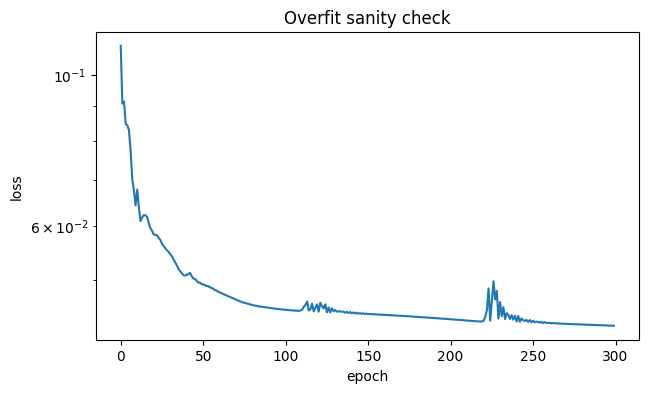

In [16]:
if CFG["overfit_debug_enabled"]:
    overfit_subset = Subset(ds_train, list(range(CFG["overfit_subset_size"])))
    overfit_loader = DataLoader(
        overfit_subset,
        batch_size=min(CFG["batch_size"], CFG["overfit_subset_size"]),
        shuffle=True, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    overfit_model = GeoDeepONet2D(token_dim=CFG['token_dim'], branch_hidden=CFG['branch_hidden'], embed_dim=CFG['embed_dim'], branch_width=CFG['branch_width'], trunk_width=CFG['trunk_width'], trunk_hidden=CFG['trunk_hidden'], num_fourier_features=CFG['num_fourier_features'], dropout=CFG['dropout'], source_aggregation=CFG['source_aggregation'], receiver_aggregation=CFG['receiver_aggregation'], H=H, W=W).to(device)
    overfit_optimizer = torch.optim.AdamW(
        overfit_model.parameters(), lr=CFG["overfit_lr"], weight_decay=0.0,
    )
    overfit_criterion = nn.MSELoss()
    overfit_scaler = torch.amp.GradScaler("cuda") if torch.cuda.is_available() else None

    overfit_history = []
    for epoch in range(1, CFG["overfit_epochs"] + 1):
        loss = train_one_epoch(
            overfit_model, overfit_loader, overfit_optimizer,
            overfit_criterion, device, scaler=overfit_scaler,
        )
        overfit_history.append(loss)
        if epoch == 1 or epoch % 20 == 0 or epoch == CFG["overfit_epochs"]:
            print(f"[overfit] epoch {epoch:03d} | loss={loss:.6f}")

    plt.figure(figsize=(7, 4))
    plt.plot(overfit_history)
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.yscale("log")
    plt.title("Overfit sanity check")
    plt.show()

    del overfit_model, overfit_optimizer, overfit_scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("overfit debug block is disabled")

## 9. Полное обучение

In [17]:
model = GeoDeepONet2D(token_dim=CFG['token_dim'], branch_hidden=CFG['branch_hidden'], embed_dim=CFG['embed_dim'], branch_width=CFG['branch_width'], trunk_width=CFG['trunk_width'], trunk_hidden=CFG['trunk_hidden'], num_fourier_features=CFG['num_fourier_features'], dropout=CFG['dropout'], source_aggregation=CFG['source_aggregation'], receiver_aggregation=CFG['receiver_aggregation'], H=H, W=W).to(device)

print(f"GeoDeepONet params: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min",
    factor=CFG["scheduler_factor"], patience=CFG["scheduler_patience"],
    min_lr=CFG["min_lr"],
)

use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if use_amp else None

RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
best_epoch = -1
best_ckpt_path = RUN_DIR / "geo_deeponet_v2_best.pt"

train_history = []
val_history = []
lr_history = []
epochs_no_improve = 0

t0 = time.time()
for epoch in range(1, CFG["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler=scaler)
    val_loss = eval_loss(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    train_history.append(train_loss)
    val_history.append(val_loss)
    lr_history.append(current_lr)

    print(f"epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.6e}")

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "stats": stats,
                "config": CFG,
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            best_ckpt_path,
        )
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= CFG["patience"]:
        print("early stopping")
        break
t1 = time.time()
print("training time sec:", t1 - t0)
print("best_epoch:", best_epoch)
print("best_val:", best_val)

GeoDeepONet params: 988,097
epoch 001 | train_loss=0.043330 | val_loss=0.041995 | lr=1.000000e-03
epoch 002 | train_loss=0.041264 | val_loss=0.042756 | lr=1.000000e-03
epoch 003 | train_loss=0.040197 | val_loss=0.041792 | lr=1.000000e-03
epoch 004 | train_loss=0.039174 | val_loss=0.037336 | lr=1.000000e-03
epoch 005 | train_loss=0.036657 | val_loss=0.036787 | lr=1.000000e-03
epoch 006 | train_loss=0.035464 | val_loss=0.033493 | lr=1.000000e-03
epoch 007 | train_loss=0.034092 | val_loss=0.033969 | lr=1.000000e-03
epoch 008 | train_loss=0.033213 | val_loss=0.032000 | lr=1.000000e-03
epoch 009 | train_loss=0.032794 | val_loss=0.032966 | lr=1.000000e-03
epoch 010 | train_loss=0.032268 | val_loss=0.031926 | lr=1.000000e-03
epoch 011 | train_loss=0.032688 | val_loss=0.030723 | lr=1.000000e-03
epoch 012 | train_loss=0.031493 | val_loss=0.032973 | lr=1.000000e-03
epoch 013 | train_loss=0.030882 | val_loss=0.032176 | lr=1.000000e-03
epoch 014 | train_loss=0.030690 | val_loss=0.030763 | lr=1.000

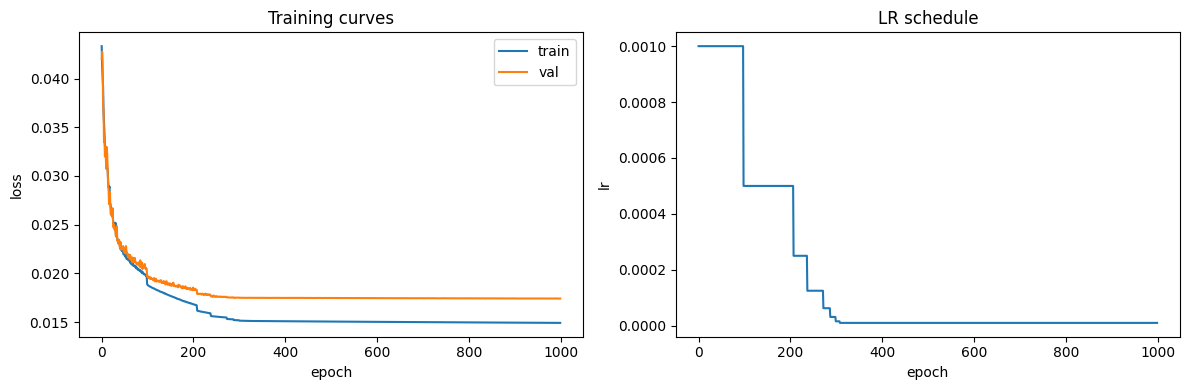

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_history, label="train")
ax[0].plot(val_history, label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("Training curves"); ax[0].legend()

ax[1].plot(lr_history)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("lr")
ax[1].set_title("LR schedule")
plt.tight_layout()
plt.show()

## 10. Best checkpoint evaluation

In [19]:
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

train_metrics = evaluate_dataset(model, ds_train, device, stats["c_min"], stats["c_max"])
val_metrics = evaluate_dataset(model, ds_val, device, stats["c_min"], stats["c_max"])
test_metrics = evaluate_dataset(model, ds_test, device, stats["c_min"], stats["c_max"])

train_summary = summarize_metrics(train_metrics)
val_summary = summarize_metrics(val_metrics)
test_summary = summarize_metrics(test_metrics)

print("TRAIN SUMMARY")
print(json.dumps(train_summary, ensure_ascii=False, indent=2))
print("\nVAL SUMMARY")
print(json.dumps(val_summary, ensure_ascii=False, indent=2))
print("\nTEST SUMMARY")
print(json.dumps(test_summary, ensure_ascii=False, indent=2))

TRAIN SUMMARY
{
  "mse_mean": 140.31125635823895,
  "mse_std": 64.61195574399552,
  "rmse_mean": 11.524049625473637,
  "rmse_std": 2.7399884180954444,
  "relative_l2_mean": 0.00772368629079973,
  "relative_l2_std": 0.0018320046320658868,
  "psnr_mean": 24.78904473403239,
  "psnr_std": 2.1393345911014343
}

VAL SUMMARY
{
  "mse_mean": 164.05225971603394,
  "mse_std": 86.06900114246156,
  "rmse_mean": 12.367526539802551,
  "rmse_std": 3.331148015275549,
  "relative_l2_mean": 0.00828641961608082,
  "relative_l2_std": 0.0022235164466509697,
  "psnr_mean": 24.24633213306337,
  "psnr_std": 2.41640374223882
}

TEST SUMMARY
{
  "mse_mean": 334.16507583618164,
  "mse_std": 178.09905302851558,
  "rmse_mean": 17.60240495622158,
  "rmse_std": 4.931573312503147,
  "relative_l2_mean": 0.011797254216508008,
  "relative_l2_std": 0.0033001892492528573,
  "psnr_mean": 21.219881041443706,
  "psnr_std": 2.5814681370879002
}


### 10.1 Geometry invariance на обученной модели

In [20]:
print("On TRAINED model:")
geom_invariance_test(model, ds_test, device, coords_device, perm_axis="receiver", perm_kind="shift", k=4)
geom_invariance_test(model, ds_test, device, coords_device, perm_axis="receiver", perm_kind="shift", k=37)
geom_invariance_test(model, ds_test, device, coords_device, perm_axis="receiver", perm_kind="random")
geom_invariance_test(model, ds_test, device, coords_device, perm_axis="source",   perm_kind="shift", k=3)
geom_invariance_test(model, ds_test, device, coords_device, perm_axis="source",   perm_kind="random")

On TRAINED model:
[geom inv / receiver / shift, k=4]  max |y0 - y1| = 4.284e-07, rel = 3.638e-07
[geom inv / receiver / shift, k=37]  max |y0 - y1| = 4.768e-07, rel = 4.049e-07
[geom inv / receiver / random, k=4]  max |y0 - y1| = 5.066e-07, rel = 4.302e-07
[geom inv / source / shift, k=3]  max |y0 - y1| = 6.147e-07, rel = 5.219e-07
[geom inv / source / random, k=4]  max |y0 - y1| = 4.768e-07, rel = 4.049e-07


(4.76837158203125e-07, 4.048792367739129e-07)

## 11. Визуализация на test

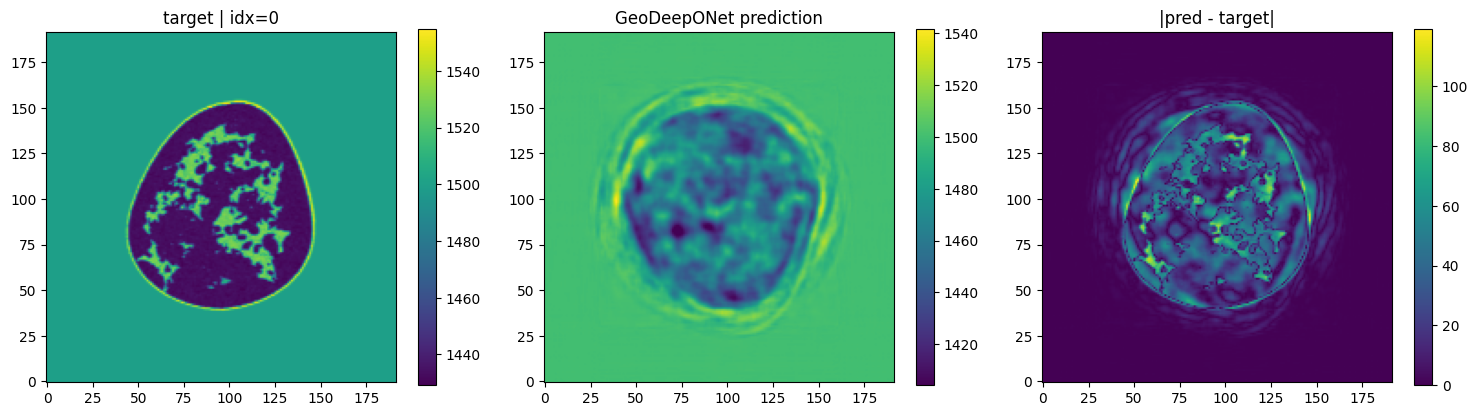

/workspace/usct_dataset_v2/test/sample_00000.npz


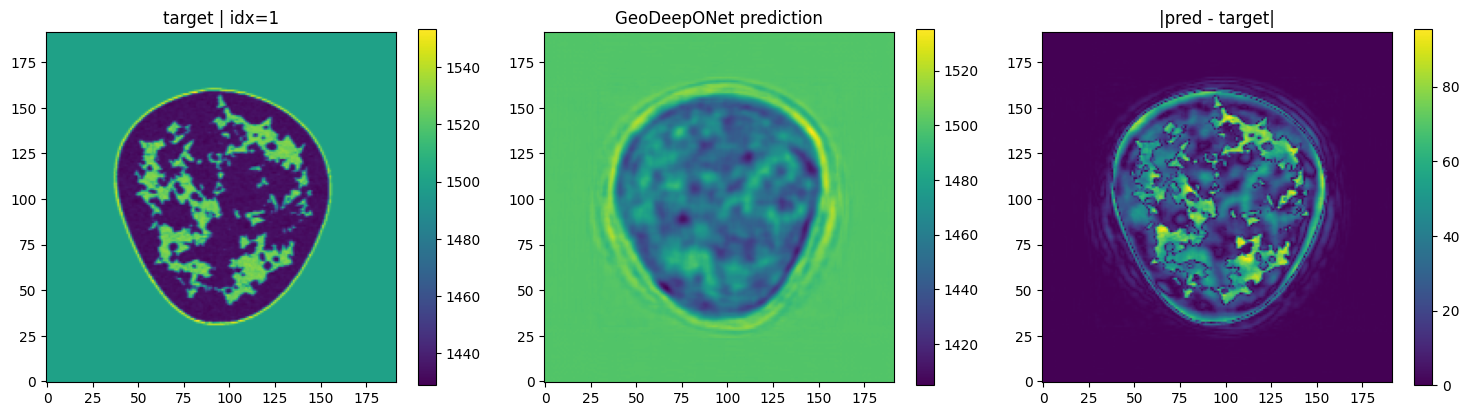

/workspace/usct_dataset_v2/test/sample_00001.npz


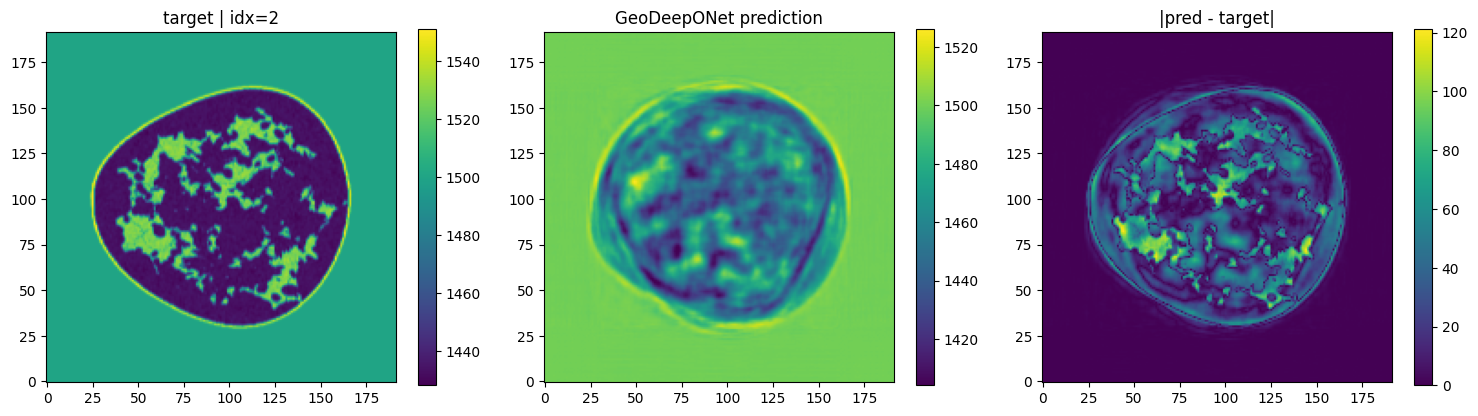

/workspace/usct_dataset_v2/test/sample_00002.npz


In [21]:
@torch.no_grad()
def show_prediction(model, dataset, idx, device, c_min, c_max):
    x, c, src_n, rcv_n, rcv_p, meta = dataset[idx]
    x      = x.unsqueeze(0).to(device)
    src_n  = src_n.unsqueeze(0).to(device)
    rcv_n  = rcv_n.unsqueeze(0).to(device)
    rcv_p  = rcv_p.unsqueeze(0).to(device)
    pred = model(x, src_n, rcv_n, coords_device)[0, 0].cpu().numpy()
    pred = np.clip(pred, -1.0, 1.0)
    target = c[0].numpy()
    pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
    target_phys = denorm_c_from_minus1_1(target, c_min, c_max)
    err = np.abs(pred_phys - target_phys)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(target_phys, origin="lower")
    ax[0].set_title(f"target | idx={idx}"); plt.colorbar(im0, ax=ax[0])
    im1 = ax[1].imshow(pred_phys, origin="lower")
    ax[1].set_title("GeoDeepONet prediction"); plt.colorbar(im1, ax=ax[1])
    im2 = ax[2].imshow(err, origin="lower")
    ax[2].set_title("|pred - target|"); plt.colorbar(im2, ax=ax[2])
    plt.tight_layout()
    plt.show()
    print(meta["path"])

for idx in [0, 1, 2]:
    show_prediction(model, ds_test, idx, device, stats["c_min"], stats["c_max"])

## 12. Save artifacts

In [22]:
with open(RUN_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "config": CFG,
            "stats": stats,
            "S": int(S), "R": int(R),
            "H": int(H), "W": int(W),
            "dx": [float(v) for v in dx],
            "freq_hz": float(freq_hz),
            "best_epoch": int(best_epoch),
            "best_val": float(best_val),
            "num_params": int(sum(p.numel() for p in model.parameters())),
        },
        f, ensure_ascii=False, indent=2,
    )

for name, payload in [
    ("train_summary.json", train_summary),
    ("val_summary.json",   val_summary),
    ("test_summary.json",  test_summary),
    ("train_metrics.json", train_metrics),
    ("val_metrics.json",   val_metrics),
    ("test_metrics.json",  test_metrics),
]:
    with open(RUN_DIR / name, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

np.savez_compressed(
    RUN_DIR / "loss_history.npz",
    train_loss=np.array(train_history, dtype=np.float32),
    val_loss=np.array(val_history, dtype=np.float32),
    lr=np.array(lr_history, dtype=np.float32),
)
print("saved GeoDeepONet artifacts to:", RUN_DIR)

saved GeoDeepONet artifacts to: /workspace/reference_points/geo_deeponet_v2
